In [242]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.neural_network import MLPClassifier

print("Libraries imported successfully")

Libraries imported successfully


<div dir="rtl" style="
    max-width: 950px;
    margin: 30px auto;
    padding: 35px 45px;
    text-align: right;
    font-size: 22px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 2px solid #d0d0d0;
    border-radius: 18px;
">

  <h1 style="
      text-align:center;
      font-size:38px;
      margin-bottom:25px;
      color:#000000;
      font-weight:800;
  ">
    פרויקט במבוא למדעי הנתונים ולמידת מכונה
  </h1>

  <p align="center">
    <img src="../assets/Handasim.png" width="430">
  </p>

  <hr style="margin: 30px 0; border: 1px solid #cccccc;">

  <h2 style="font-size:30px; color:#000000; font-weight:800;">דף שער</h2>

  <p><b>שם הסטודנט:</b> מוחמד ריאן</p>

  <p><b>כיתה:</b> 50/2</p>

  <p><b>שנת לימודים:</b> 2026</p>

  <p><b>שם המורה:</b> אירנה</p>

  <p><b>שם הפרויקט:</b> חיזוי רמת מחיר של בתים בעזרת למידת מכונה</p>

  <h2 style="
      font-size:30px;
      margin-top:30px;
      color:#000000;
      font-weight:800;
  ">
    שאלת המחקר
  </h2>

  <p>
    האם ניתן לחזות אם בית שייך לקבוצת מחיר גבוה או מחיר נמוך לפי מאפיינים פיזיים של הבית,
    כגון שטח מגורים, מספר חדרי רחצה, מספר חדרי שינה, מספר קומות, נוף ומצב הבית?
  </p>

  <h2 style="
      font-size:30px;
      margin-top:30px;
      color:#000000;
      font-weight:800;
  ">
    תיאור כללי של הפרויקט
  </h2>

  <p>
    בפרויקט זה נשתמש בקובץ נתונים של בתים ונבצע תהליך מלא של מדעי הנתונים:
    טעינת הנתונים, חקר נתונים, ניקוי נתונים, הנדסת מאפיינים, בדיקת קורלציה,
    חלוקה לנתוני אימון ובדיקה, נירמול הנתונים, אימון מודל KNN ואימון מודל ANN.
  </p>

  <p>
    המטרה היא להפוך את עמודת המחיר מבעיה של רגרסיה לבעיה של סיווג,
    ולחזות האם הבית נמצא בקבוצת מחיר נמוך או בקבוצת מחיר גבוה.
  </p>

  <p align="center" style="margin-top:35px;">
    <img src="../assets/cover.png" width="760" style="border-radius: 16px;">
  </p>

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 28px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h1 style="color:#000000; font-weight:800;">2. תיאור הנתונים</h1>

<p>
קובץ הנתונים שבו נשתמש בפרויקט הוא:
</p>

<p style="direction:ltr; text-align:left;">
<b>data/data_House.csv</b>
</p>

<p>
הקובץ מכיל נתונים על בתים. כל שורה מייצגת בית אחד, וכל עמודה מייצגת מאפיין של הבית.
מטרת הפרויקט היא להשתמש במאפייני הבית כדי לחזות האם הבית שייך לקבוצת מחיר נמוך או לקבוצת מחיר גבוה.
</p>

<h2 style="color:#000000; font-weight:800;">הסבר על העמודות בקובץ המקורי</h2>

<table style="width:100%; border-collapse: collapse; font-size:18px;">
<tr style="background-color:#eeeeee;">
<th style="border:1px solid #999; padding:8px;">עמודה</th>
<th style="border:1px solid #999; padding:8px;">הסבר</th>
<th style="border:1px solid #999; padding:8px;">סוג נתון</th>
</tr>

<tr><td style="border:1px solid #999; padding:8px;">date</td><td style="border:1px solid #999; padding:8px;">תאריך מכירת הבית. בהמשך נמחק עמודה זו כי לא נשתמש בתאריך במודל.</td><td style="border:1px solid #999; padding:8px;">תאריך / טקסט</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">price</td><td style="border:1px solid #999; padding:8px;">מחיר הבית. זהו המשתנה המרכזי בפרויקט, וממנו ניצור את עמודת המטרה Price_Level.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">bedrooms</td><td style="border:1px solid #999; padding:8px;">מספר חדרי השינה בבית.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">bathrooms</td><td style="border:1px solid #999; padding:8px;">מספר חדרי הרחצה בבית.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">sqft_living</td><td style="border:1px solid #999; padding:8px;">שטח המגורים של הבית ברגל רבוע.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">sqft_lot</td><td style="border:1px solid #999; padding:8px;">שטח המגרש של הבית ברגל רבוע.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">floors</td><td style="border:1px solid #999; padding:8px;">מספר הקומות בבית.</td><td style="border:1px solid #999; padding:8px;">בדיד / רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">waterfront</td><td style="border:1px solid #999; padding:8px;">האם הבית נמצא ליד מים. 0 = לא, 1 = כן.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">view</td><td style="border:1px solid #999; padding:8px;">רמת הנוף של הבית.</td><td style="border:1px solid #999; padding:8px;">בדיד / סדר</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">condition</td><td style="border:1px solid #999; padding:8px;">מצב הבית.</td><td style="border:1px solid #999; padding:8px;">בדיד / סדר</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">sqft_above</td><td style="border:1px solid #999; padding:8px;">שטח הבית מעל הקרקע.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">sqft_basement</td><td style="border:1px solid #999; padding:8px;">שטח המרתף של הבית. ערך 0 אומר שאין מרתף.</td><td style="border:1px solid #999; padding:8px;">רציף</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">yr_built</td><td style="border:1px solid #999; padding:8px;">שנת בניית הבית.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">yr_renovated</td><td style="border:1px solid #999; padding:8px;">שנת השיפוץ של הבית. ערך 0 אומר שהבית לא שופץ.</td><td style="border:1px solid #999; padding:8px;">בדיד</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">street</td><td style="border:1px solid #999; padding:8px;">כתובת הרחוב. בהמשך נמחק עמודה זו כי היא טקסטואלית.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">city</td><td style="border:1px solid #999; padding:8px;">שם העיר. בפרויקט זה נמחק עמודה זו לפי החלטת הפרויקט.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">statezip</td><td style="border:1px solid #999; padding:8px;">מדינה ומיקוד. בפרויקט זה נמחק עמודה זו.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>

<tr><td style="border:1px solid #999; padding:8px;">country</td><td style="border:1px solid #999; padding:8px;">מדינה. בפרויקט זה נמחק עמודה זו כי היא אינה מוסיפה מידע משמעותי למודל.</td><td style="border:1px solid #999; padding:8px;">שמי</td></tr>

</table>

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 25px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h1 style="color:#000000; font-weight:800;">3. בדיקת הנתונים הראשונית</h1>

<p>
בשלב זה נבדוק את מבנה הנתונים: מספר שורות ועמודות, סוגי הנתונים בכל עמודה,
כמות ערכים מלאים, כמות ערכים חסרים ומספר ערכים ייחודיים בכל עמודה.
</p>

</div>

In [243]:
data_path = Path("../data/data_House.csv")

if not data_path.exists():
    data_path = Path("data/data_House.csv")

df = pd.read_csv(data_path)

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully
Dataset shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [244]:
# Initial data check

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nComplete records in each column:")
print(df.count())

print("\nNumber of unique values in each column:")
print(df.nunique())

Dataset shape:
(4600, 18)

Column names:
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

Data types:
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

Missing values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above   

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 25px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h1 style="color:#000000; font-weight:800;">4. חקר נתונים - Exploratory Data Analysis</h1>

<p>
בשלב זה נבצע חקר ראשוני של הנתונים.  
נבדוק מדדים סטטיסטיים בסיסיים כמו ממוצע, סטיית תקן, ערך מינימלי, חציון וערך מקסימלי.
</p>

<p>
הבדיקה עוזרת להבין את טווח הערכים בנתונים ולזהות מאפיינים חשובים שיכולים להשפיע על מחיר הבית.
</p>

</div>

In [245]:
# Descriptive statistics

df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [246]:
# Descriptive statistics in a clearer table

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.000000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.000000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.000000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.000000,2300.00,9410.0


In [247]:
# Important statistics for price and living area

print("Price statistics:")
print("Mean price:", df['price'].mean())
print("Median price:", df['price'].median())
print("Minimum price:", df['price'].min())
print("Maximum price:", df['price'].max())

print("\nLiving area statistics:")
print("Mean sqft_living:", df['sqft_living'].mean())
print("Median sqft_living:", df['sqft_living'].median())
print("Minimum sqft_living:", df['sqft_living'].min())
print("Maximum sqft_living:", df['sqft_living'].max())

Price statistics:
Mean price: 551962.9884732141
Median price: 460943.46153850004
Minimum price: 0.0
Maximum price: 26590000.0

Living area statistics:
Mean sqft_living: 2139.3469565217392
Median sqft_living: 1980.0
Minimum sqft_living: 370
Maximum sqft_living: 13540


<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 25px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h2 style="color:#000000; font-weight:800;">מסקנה</h2>

<p>
מהטבלה הסטטיסטית ניתן לראות את הערכים המרכזיים של הנתונים:
ממוצע, סטיית תקן, מינימום, חציון ומקסימום.
</p>

<p>
עמודת <b>price</b> מייצגת את מחיר הבית, ועמודת <b>sqft_living</b> מייצגת את שטח המגורים.
אלו שתי עמודות חשובות במיוחד בפרויקט, כי המטרה שלנו היא לבדוק איך מאפיינים פיזיים של הבית קשורים לרמת המחיר שלו.
</p>

<p>
בהמשך נשתמש בעמודת המחיר כדי ליצור עמודת מטרה חדשה בשם <b>Price_Level</b>,
וכך נהפוך את הבעיה מבעיית רגרסיה לבעיית סיווג.
</p>

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 25px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h1 style="color:#000000; font-weight:800;">5. ניקוי נתונים והנדסת מאפיינים</h1>

<p>
בשלב זה נבצע ניקוי נתונים ונכין את הנתונים ללמידת מכונה.
</p>

<p>
נמחק עמודות שלא נשתמש בהן במודל:
<b>date</b>, <b>street</b>, <b>city</b>, <b>statezip</b>, <b>country</b>.
</p>

<p>
בנוסף, נבדוק אם קיימים ערכים חסרים בנתונים.
אם יהיו ערכים חסרים, נמלא אותם בעזרת החציון של אותה עמודה ולא נמחק שורות.
</p>

<p>
לאחר מכן נהפוך את עמודת <b>price</b> מבעיה של רגרסיה לבעיה של סיווג.
ניצור עמודת מטרה חדשה בשם <b>Price_Level</b>:
</p>

<ul>
  <li><b>0</b> = מחיר נמוך או שווה לחציון</li>
  <li><b>1</b> = מחיר גבוה מהחציון</li>
</ul>

</div>

In [248]:
# Data Cleaning and Feature Engineering

print("Shape before cleaning:", df.shape)

# Small check: count houses with price = 0
zero_price_count = (df['price'] == 0).sum()
print("Number of houses with price = 0:", zero_price_count)

# Delete columns that will not be used in the model
columns_to_delete = ['date', 'street', 'city', 'statezip', 'country']
df = df.drop(columns=columns_to_delete)

print("Shape after deleting columns:", df.shape)

# Check missing values
print("\nMissing values before filling:")
print(df.isnull().sum())

# Fill missing numeric values with median if needed
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\nTotal missing values after cleaning:", df.isnull().sum().sum())

# Convert regression problem into classification problem
median_price = df['price'].median()
print("\nMedian price:", median_price)

df['Price_Level'] = (df['price'] > median_price).astype('int64')

# Drop original price column to prevent data leakage
df = df.drop('price', axis=1)

print("\nTarget balance:")
print(df['Price_Level'].value_counts())

df.head()

Shape before cleaning: (4600, 18)
Number of houses with price = 0: 49
Shape after deleting columns: (4600, 13)

Missing values before filling:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
dtype: int64

Total missing values after cleaning: 0

Median price: 460943.46153850004

Target balance:
Price_Level
0    2300
1    2300
Name: count, dtype: int64


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,Price_Level
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,0
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,1
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,1


<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 25px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h2 style="color:#000000; font-weight:800;">מסקנה</h2>

<p>
בשלב ניקוי הנתונים מחקנו רק עמודות שלא נשתמש בהן במודל:
<b>date</b>, <b>street</b>, <b>city</b>, <b>statezip</b>, <b>country</b>.
לא מחקנו שורות מהנתונים, ולכן נשארו 4600 רשומות.
</p>

<p>
בבדיקת הערכים החסרים נמצא שאין ערכים חסרים לאחר הניקוי.
בנוסף, קיימים 49 בתים שבהם המחיר הוא 0, אך בפרויקט זה לא מחקנו שורות ולכן השארנו אותם כחלק מהנתונים המקוריים.
</p>

<p>
יצרנו עמודת מטרה חדשה בשם <b>Price_Level</b> לפי החציון של המחיר.
לאחר החלוקה התקבלו שתי קבוצות מאוזנות:
2300 בתים בקבוצת מחיר נמוך ו־2300 בתים בקבוצת מחיר גבוה.
לכן אין צורך לבצע איזון נתונים.
</p>

<p>
לבסוף מחקנו את עמודת <b>price</b> המקורית כדי למנוע מצב שבו המודל מקבל את התשובה האמיתית בזמן האימון.
</p>

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 25px 40px;
    text-align: right;
    font-size: 21px;
    line-height: 1.9;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h1 style="color:#000000; font-weight:800;">6. ויזואליזציה של הנתונים</h1>

<p>
בשלב זה נציג מספר גרפים שיעזרו להבין את הקשר בין מאפייני הבית לבין רמת המחיר.
</p>

<p>
נשתמש בגרפים שונים כמו Count Plot, Histogram, Box Plot, Bar Plot ו־Scatter Plot.
בכל גרף נציין את סוג הנתונים ונסביר את המסקנה.
</p>

</div>

In [249]:
# Visualization settings

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["xtick.labelsize"] = 13
plt.rcParams["ytick.labelsize"] = 13

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 22px 35px;
    text-align: right;
    font-size: 21px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h2 style="color:#000000; font-weight:800;">גרף 1: כמות הבתים בכל רמת מחיר</h2>

<p>
סוג הנתונים: <b>בדיד</b>.  
העמודה <b>Price_Level</b> כוללת שתי קטגוריות:
0 = מחיר נמוך, 1 = מחיר גבוה.
</p>

</div>

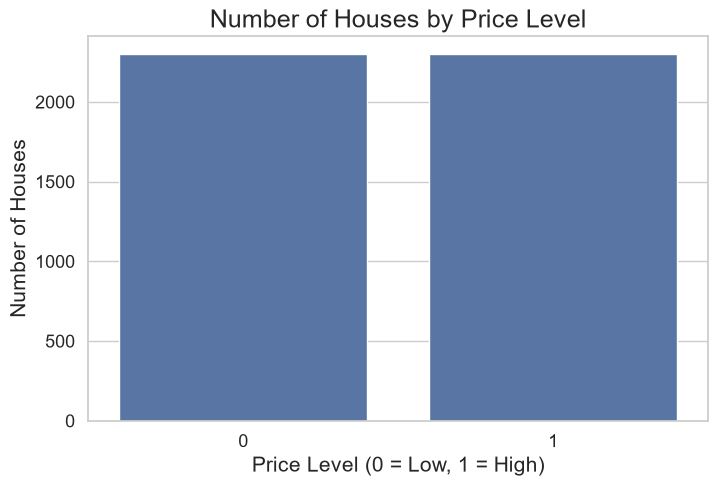

In [250]:
# Graph 1: Count plot of Price_Level

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Price_Level")

plt.title("Number of Houses by Price Level")
plt.xlabel("Price Level (0 = Low, 1 = High)")
plt.ylabel("Number of Houses")

plt.show()

<div dir="rtl" style="
    max-width: 950px;
    margin: 15px auto 30px auto;
    padding: 18px 30px;
    text-align: right;
    font-size: 20px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 14px;
">

<b>מסקנה:</b>
ניתן לראות שהנתונים מאוזנים: יש מספר שווה של בתים בקבוצת המחיר הנמוך ובקבוצת המחיר הגבוה.
לכן אין צורך לבצע איזון נתונים.

</div>

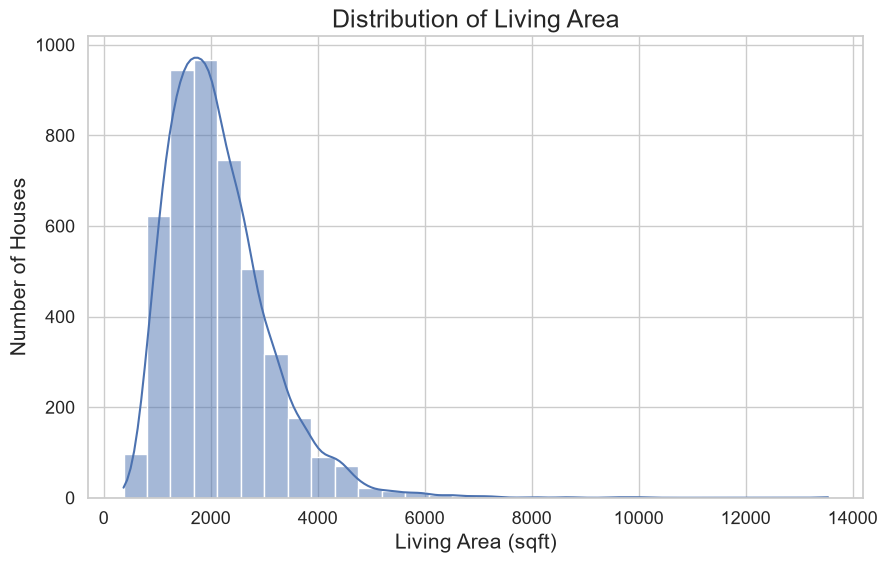

In [251]:
# Graph 2: Histogram of sqft_living

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="sqft_living", bins=30, kde=True)

plt.title("Distribution of Living Area")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Number of Houses")

plt.show()

<div dir="rtl" style="
    max-width: 950px;
    margin: 15px auto 30px auto;
    padding: 18px 30px;
    text-align: right;
    font-size: 20px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 14px;
">

<b>מסקנה:</b>
ניתן לראות שרוב הבתים נמצאים בטווח שטח מגורים מסוים, ויש פחות בתים עם שטח מגורים גדול מאוד.
המאפיין הזה חשוב כי שטח מגורים גדול יותר יכול להשפיע על רמת המחיר של הבית.

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 22px 35px;
    text-align: right;
    font-size: 21px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h2 style="color:#000000; font-weight:800;">גרף 3: שטח מגורים לפי רמת מחיר</h2>

<p>
סוג הנתונים: <b>רציף + בדיד</b>.  
הגרף מציג את הקשר בין שטח המגורים של הבית <b>sqft_living</b> לבין רמת המחיר <b>Price_Level</b>.
</p>

</div>

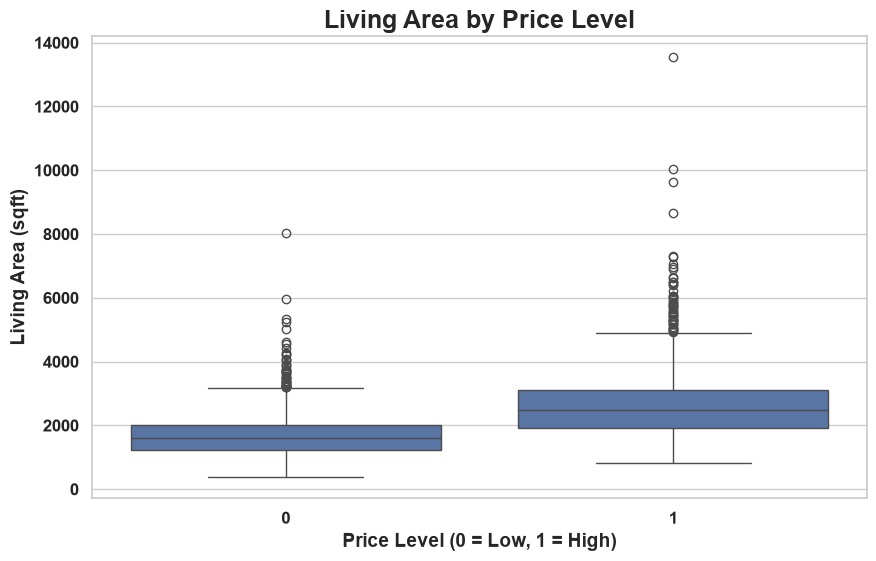

In [252]:
# Graph 3: Living area by price level

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Price_Level',
    y='sqft_living'
)

plt.title('Living Area by Price Level', fontsize=18, fontweight='bold')
plt.xlabel('Price Level (0 = Low, 1 = High)', fontsize=14, fontweight='bold')
plt.ylabel('Living Area (sqft)', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.show()

<div dir="rtl" style="
    max-width: 950px;
    margin: 15px auto 30px auto;
    padding: 18px 30px;
    text-align: right;
    font-size: 20px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 14px;
">

<b>מסקנה:</b>
ניתן לראות שבתים בקבוצת המחיר הגבוה נוטים להיות בעלי שטח מגורים גדול יותר.
לכן <b>sqft_living</b> הוא מאפיין חשוב לחיזוי רמת המחיר של הבית.

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 22px 35px;
    text-align: right;
    font-size: 21px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h2 style="color:#000000; font-weight:800;">גרף 4: ממוצע חדרי רחצה לפי רמת מחיר</h2>

<p>
סוג הנתונים: <b>רציף + בדיד</b>.  
הגרף מציג את ממוצע מספר חדרי הרחצה בכל קבוצת מחיר.
</p>

</div>

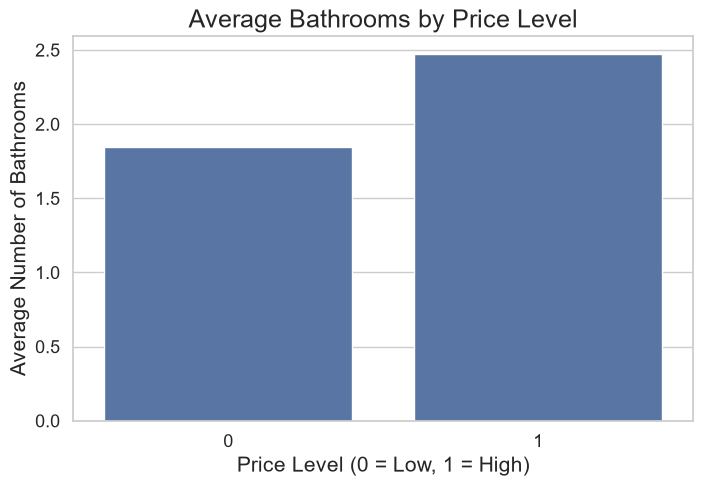

In [253]:
# Graph 4: Average bathrooms by Price_Level

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Price_Level", y="bathrooms", errorbar=None)

plt.title("Average Bathrooms by Price Level")
plt.xlabel("Price Level (0 = Low, 1 = High)")
plt.ylabel("Average Number of Bathrooms")

plt.show()

<div dir="rtl" style="
    max-width: 950px;
    margin: 15px auto 30px auto;
    padding: 18px 30px;
    text-align: right;
    font-size: 20px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 14px;
">

<b>מסקנה:</b>
ניתן לראות שבתים בקבוצת המחיר הגבוה כוללים בממוצע יותר חדרי רחצה.
לכן גם מספר חדרי הרחצה יכול לעזור למודל להבדיל בין מחיר נמוך למחיר גבוה.

</div>

<div dir="rtl" style="
    max-width: 950px;
    margin: 25px auto;
    padding: 22px 35px;
    text-align: right;
    font-size: 21px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 16px;
">

<h2 style="color:#000000; font-weight:800;">גרף 5: קשר בין שטח מגורים, חדרי רחצה ורמת מחיר</h2>

<p>
סוג הנתונים: <b>שני משתנים רציפים + משתנה בדיד</b>.  
הגרף מציג את הקשר בין <b>sqft_living</b> ו־<b>bathrooms</b>, כאשר הצבע מייצג את רמת המחיר.
</p>

</div>

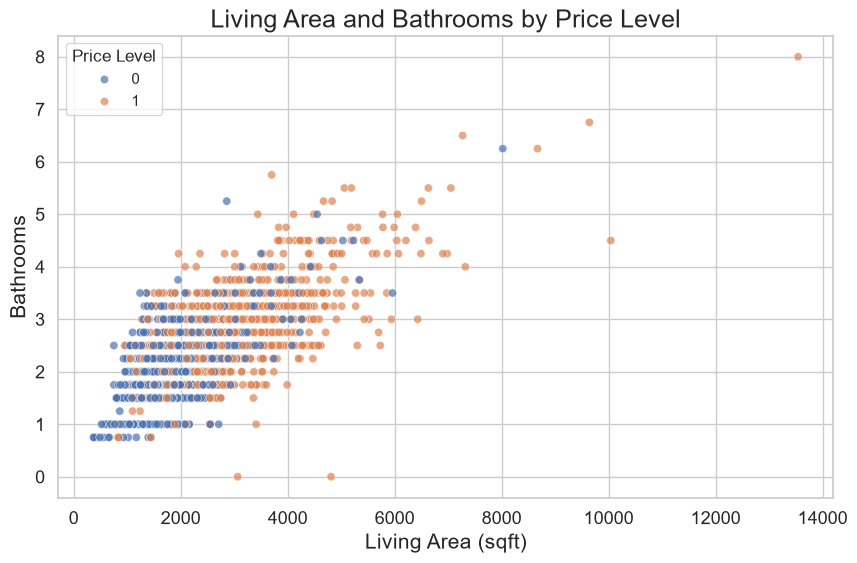

In [254]:
# Graph 5: Scatter plot of sqft_living and bathrooms by Price_Level

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="sqft_living",
    y="bathrooms",
    hue="Price_Level",
    alpha=0.7
)

plt.title("Living Area and Bathrooms by Price Level")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Bathrooms")
plt.legend(title="Price Level")

plt.show()

<div dir="rtl" style="
    max-width: 950px;
    margin: 15px auto 30px auto;
    padding: 18px 30px;
    text-align: right;
    font-size: 20px;
    line-height: 1.8;
    background-color: #ffffff;
    color: #111111;
    font-weight: 600;
    border: 1px solid #d0d0d0;
    border-radius: 14px;
">

<b>מסקנה:</b>
מהגרף ניתן לראות שבתים בעלי שטח מגורים גדול יותר ומספר חדרי רחצה גבוה יותר נוטים להופיע יותר בקבוצת המחיר הגבוה.
מסקנה זו מתאימה לשאלת המחקר ומראה שיש קשר בין מאפיינים פיזיים של הבית לבין רמת המחיר.

</div>